In [23]:
!pip install opencv-python-headless scikit-learn matplotlib numpy scipy imutils -q

import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, deque
from scipy.spatial import distance as dist
import os, time, datetime, warnings
from google.colab import files
warnings.filterwarnings('ignore')

print('Done. OpenCV: ' + cv2.__version__)

Done. OpenCV: 4.13.0


In [24]:
CONFIG = {
    'FRAME_WIDTH': 640, 'FRAME_HEIGHT': 480,
    'HOG_WIN_STRIDE': (8, 8), 'HOG_PADDING': (4, 4), 'HOG_SCALE': 1.05,
    'NMS_THRESHOLD': 0.45, 'HUMAN_CONF_THRESH': 0.5,
    'MOG2_HISTORY': 500, 'MOG2_VAR_THRESH': 25, 'MOG2_DETECT_SHADOW': True,
    'MORPH_KERNEL': (5, 5), 'MIN_CONTOUR_AREA': 800,
    'IDLE_SPEED': 2.0, 'WALKING_SPEED': 10.0,
    'LINGER_FRAMES': 90, 'ANIMAL_STILL_FRAMES': 1800,
    'ALERT_COOLDOWN_S': 5,
    'LOG_FILE': '/content/surveillance_log.txt',
    'OUTPUT_VIDEO': '/content/surveillance_output.avi',
}
BEHAVIOR_COLORS = {
    'idle': (100, 200, 100), 'walking': (200, 150, 50),
    'lingering': (50, 170, 240), 'suspicious': (50, 50, 220), 'running': (0, 100, 255),
}
print('Config loaded.')

Config loaded.


In [32]:
import cv2
import numpy as np
import datetime

def generate_mp4(path='/content/surveillance_test.mp4', n_frames=300, fps=20):
    W, H = 640, 480
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(path, fourcc, fps, (W, H))

    entities = [
        [80,  200, 2.5,  0.5, 40, 90, 'human',  (180, 120, 60)],
        [500, 300, -1.8, 1.0, 40, 90, 'human',  (60,  120, 180)],
        [300, 380, 3.0,  0.0, 60, 35, 'animal', (60,  180, 60)],
        [200, 250, 1.2, -0.8, 70, 40, 'animal', (80,  160, 80)],
    ]

    bg = np.zeros((H, W, 3), dtype=np.uint8)
    bg[:] = (34, 45, 32)
    cv2.rectangle(bg, (0, 0), (W, H//3), (65, 62, 78), -1)
    cv2.rectangle(bg, (50, 80), (180, 210), (42, 38, 110), -1)
    cv2.rectangle(bg, (50, 78), (180, 95), (55, 50, 130), -1)
    cv2.rectangle(bg, (480, 90), (600, 190), (42, 38, 110), -1)
    cv2.line(bg, (0, H//3), (W, H//3), (48, 78, 45), 2)
    cv2.line(bg, (0, H//3+1), (W, H//3+1), (38, 65, 38), 1)
    for i in range(0, W, 60):
        cv2.line(bg, (i, H//3), (i, H), (40, 55, 38), 1)

    print('Generating MP4 video...')
    for f in range(n_frames):
        frame = bg.copy()
        noise = np.random.randint(0, 6, frame.shape, dtype=np.uint8)
        frame = cv2.add(frame, noise)

        for e in entities:
            e[0] += e[2]
            e[1] += e[3]
            if e[0] < 10 or e[0] > W - e[4] - 10: e[2] *= -1
            if e[1] < H//3 or e[1] > H - e[5] - 10: e[3] *= -1
            x, y, w, h = int(e[0]), int(e[1]), e[4], e[5]

            if e[6] == 'human':
                cv2.ellipse(frame, (x+w//2, y+8), (9, 9), 0, 0, 360, e[7], -1)
                cv2.rectangle(frame, (x+6, y+18), (x+w-6, y+h-22), e[7], -1)
                cv2.line(frame, (x+10, y+h-22), (x+4,  y+h),    e[7], 3)
                cv2.line(frame, (x+w-10, y+h-22),(x+w-4, y+h),  e[7], 3)
                cv2.line(frame, (x+8,  y+22), (x+2,  y+45), e[7], 2)
                cv2.line(frame, (x+w-8, y+22),(x+w-2, y+45), e[7], 2)
            else:
                cv2.ellipse(frame, (x+w//2, y+h//2), (w//2, h//3), 0, 0, 360, e[7], -1)
                cv2.ellipse(frame, (x+w-8, y+4), (6, 5), 0, 0, 360, e[7], -1)
                cv2.line(frame, (x+8,  y+h//2+5), (x+4,  y+h+4), e[7], 2)
                cv2.line(frame, (x+16, y+h//2+5), (x+12, y+h+4), e[7], 2)
                cv2.line(frame, (x+w-8,  y+h//2+5),(x+w-4,  y+h+4), e[7], 2)
                cv2.line(frame, (x+w-16, y+h//2+5),(x+w-12, y+h+4), e[7], 2)

        if 150 <= f <= 220:
            entities[0][2] = 5.5
            entities[0][3] = 3.5
        elif f == 221:
            entities[0][2] = 2.5
            entities[0][3] = 0.5

        ts = 'CAM-01  FRAME ' + str(f).zfill(4) + '  ' + datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        cv2.putText(frame, ts, (6, 15), cv2.FONT_HERSHEY_SIMPLEX, 0.38, (200, 200, 200), 1)

        if (f // 15) % 2 == 0:
            cv2.circle(frame, (W-14, 12), 4, (50, 50, 220), -1)
            cv2.putText(frame, 'REC', (W-42, 16), cv2.FONT_HERSHEY_SIMPLEX, 0.35, (200, 200, 200), 1)

        out.write(frame)

    out.release()
    print('Done! Saved to: ' + path)
    return path


VIDEO_PATH = generate_mp4()

cap = cv2.VideoCapture(VIDEO_PATH)
print('Frames : ' + str(int(cap.get(cv2.CAP_PROP_FRAME_COUNT))))
print('FPS    : ' + str(cap.get(cv2.CAP_PROP_FPS)))
print('Size   : ' + str(int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))) +
      'x' + str(int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))))
cap.release()

Generating MP4 video...
Done! Saved to: /content/surveillance_test.mp4
Frames : 300
FPS    : 20.0
Size   : 640x480


In [33]:
VIDEO_PATH = '/content/surveillance_test.mp4'
print('Video path set: ' + VIDEO_PATH)

Video path set: /content/surveillance_test.mp4


In [34]:
from IPython.display import HTML
from base64 import b64encode

def show_video(path):
    mp4 = open(path, 'rb').read()
    data_url = 'data:video/mp4;base64,' + b64encode(mp4).decode()
    return HTML('''
    <video width="640" height="480" controls autoplay loop>
        <source src="''' + data_url + '''" type="video/mp4">
    </video>
    ''')

print('Original test video:')
show_video('/content/surveillance_test.mp4')

Original test video:


In [25]:
def generate_test_video(path='/content/test_video.avi', n_frames=300, fps=20):
    W, H = CONFIG['FRAME_WIDTH'], CONFIG['FRAME_HEIGHT']
    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    out = cv2.VideoWriter(path, fourcc, fps, (W, H))
    entities = [
        [80,  200, 2.5,  0.5, 40, 90, 'human',  (180, 120, 60)],
        [500, 300, -1.8, 1.0, 40, 90, 'human',  (60,  120, 180)],
        [300, 380, 3.0,  0.0, 60, 35, 'animal', (60,  180, 60)],
    ]
    bg = np.zeros((H, W, 3), dtype=np.uint8)
    bg[:] = (30, 40, 30)
    cv2.rectangle(bg, (0, 0), (W, H//3), (60, 60, 80), -1)
    cv2.rectangle(bg, (50, 100), (160, 200), (40, 40, 120), -1)
    cv2.line(bg, (0, H//3), (W, H//3), (50, 80, 50), 2)
    for f in range(n_frames):
        frame = bg.copy()
        noise = np.random.randint(0, 8, frame.shape, dtype=np.uint8)
        frame = cv2.add(frame, noise)
        for e in entities:
            e[0] += e[2]
            e[1] += e[3]
            if e[0] < 0 or e[0] > W - e[4]: e[2] *= -1
            if e[1] < 0 or e[1] > H - e[5]: e[3] *= -1
            x, y, w, h = int(e[0]), int(e[1]), e[4], e[5]
            if e[6] == 'human':
                cv2.ellipse(frame, (x+w//2, y+10), (10, 10), 0, 0, 360, e[7], -1)
                cv2.rectangle(frame, (x+5, y+20), (x+w-5, y+h-20), e[7], -1)
                cv2.line(frame, (x+10, y+h-20), (x+5, y+h), e[7], 4)
                cv2.line(frame, (x+w-10, y+h-20), (x+w-5, y+h), e[7], 4)
            else:
                cv2.ellipse(frame, (x+w//2, y+h//2), (w//2, h//2), 0, 0, 360, e[7], -1)
        ts = 'FRAME ' + str(f).zfill(4) + '  ' + datetime.datetime.now().strftime('%H:%M:%S')
        cv2.putText(frame, ts, (5, 15), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (200, 200, 200), 1)
        if 150 <= f <= 220:
            entities[0][2] = 5.0
            entities[0][3] = 3.0
        elif f == 221:
            entities[0][2] = 2.5
            entities[0][3] = 0.5
        out.write(frame)
    out.release()
    print('Test video saved: ' + path)
    return path

USE_OWN_VIDEO = False
if USE_OWN_VIDEO:
    uploaded = files.upload()
    VIDEO_PATH = list(uploaded.keys())[0]
else:
    VIDEO_PATH = generate_test_video()

cap = cv2.VideoCapture(VIDEO_PATH)
print('Frames: ' + str(int(cap.get(cv2.CAP_PROP_FRAME_COUNT))) +
      '  FPS: ' + str(cap.get(cv2.CAP_PROP_FPS)) +
      '  Size: ' + str(int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))) +
      'x' + str(int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))))
cap.release()

Test video saved: /content/test_video.avi
Frames: 300  FPS: 20.0  Size: 640x480


In [26]:
!pip install yt-dlp -q
!yt-dlp -f "best[height<=480][ext=mp4]" -o /content/test_video.mp4 "https://www.youtube.com/watch?v=ByED80IKdIU"

import subprocess
subprocess.run(['ffmpeg', '-i', '/content/test_video.mp4',
                '-vcodec', 'libx264', '-acodec', 'aac',
                '/content/test_video_conv.mp4', '-y'], capture_output=True)

VIDEO_PATH = '/content/test_video_conv.mp4'

cap = cv2.VideoCapture(VIDEO_PATH)
print('Frames : ' + str(int(cap.get(cv2.CAP_PROP_FRAME_COUNT))))
print('FPS    : ' + str(cap.get(cv2.CAP_PROP_FPS)))
print('Size   : ' + str(int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))) +
      'x' + str(int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))))
cap.release()

[youtube] Extracting URL: https://www.youtube.com/watch?v=ByED80IKdIU
[youtube] ByED80IKdIU: Downloading webpage
[youtube] ByED80IKdIU: Downloading android vr player API JSON
ERROR: [youtube] ByED80IKdIU: This live stream recording is not available.
Frames : 0
FPS    : 0.0
Size   : 0x0


In [27]:
class Preprocessor:
    def __init__(self):
        self.w = CONFIG['FRAME_WIDTH']
        self.h = CONFIG['FRAME_HEIGHT']

    def process(self, frame):
        resized   = cv2.resize(frame, (self.w, self.h))
        gray      = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
        blurred   = cv2.GaussianBlur(gray, (5, 5), 0)
        equalized = cv2.equalizeHist(blurred)
        return {'original': frame, 'resized': resized,
                'gray': gray, 'blurred': blurred, 'equalized': equalized}

preprocessor = Preprocessor()
cap = cv2.VideoCapture(VIDEO_PATH)
ret, sample_frame = cap.read()
cap.release()

# Check if a frame was successfully read
if sample_frame is not None:
    pp = preprocessor.process(sample_frame)

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    titles = ['Original', 'Resized', 'Blurred', 'Equalized']
    imgs   = [pp['original'], pp['resized'], pp['blurred'], pp['equalized']]
    cmaps  = [None, None, 'gray', 'gray']
    for ax, img, title, cmap in zip(axes, imgs, titles, cmaps):
        ax.imshow(img if cmap else cv2.cvtColor(img, cv2.COLOR_BGR2RGB), cmap=cmap)
        ax.set_title(title, fontweight='bold')
        ax.axis('off')
    plt.suptitle('Stage 1 and 2 - Preprocessing', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print(f"Warning: No frame could be read from the video at '{VIDEO_PATH}'. "
          "The video might be empty or corrupted. "
          "Skipping preprocessing visualization.")

print('Preprocessor ready.')

Preprocessor ready.


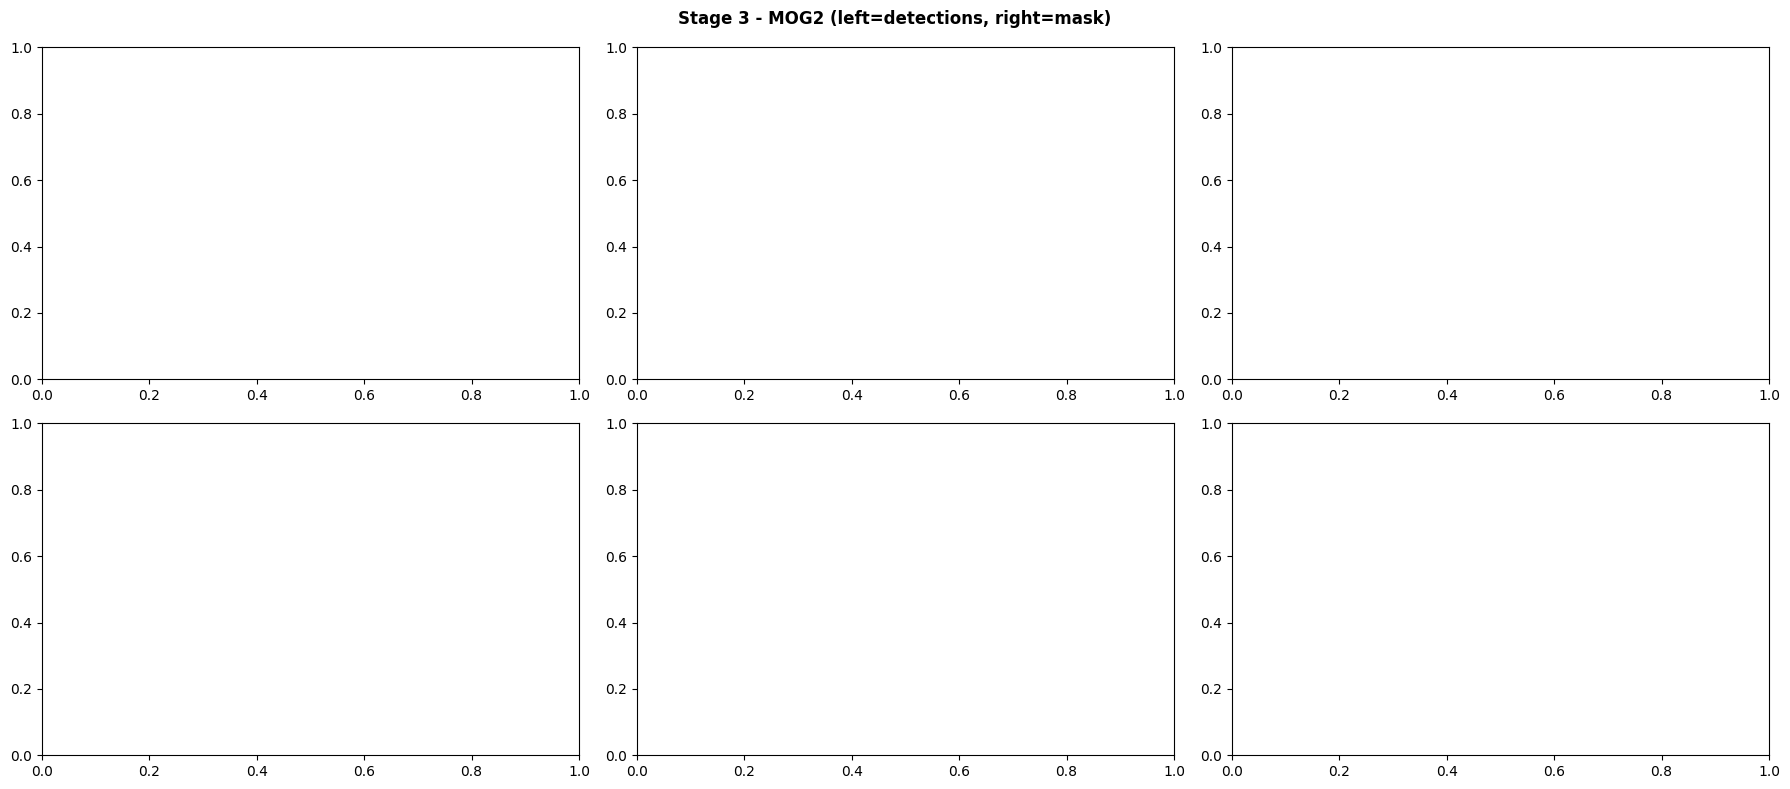

Animal detector ready.


In [28]:
class AnimalDetector:
    def __init__(self):
        self.mog2 = cv2.createBackgroundSubtractorMOG2(
            history=CONFIG['MOG2_HISTORY'],
            varThreshold=CONFIG['MOG2_VAR_THRESH'],
            detectShadows=CONFIG['MOG2_DETECT_SHADOW']
        )
        self.kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, CONFIG['MORPH_KERNEL'])

    def detect(self, frame):
        fg = self.mog2.apply(frame)
        _, fg = cv2.threshold(fg, 200, 255, cv2.THRESH_BINARY)
        fg = cv2.erode(fg, self.kernel, iterations=1)
        fg = cv2.dilate(fg, self.kernel, iterations=3)
        contours, _ = cv2.findContours(fg, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        boxes = []
        for cnt in contours:
            if cv2.contourArea(cnt) < CONFIG['MIN_CONTOUR_AREA']:
                continue
            x, y, w, h = cv2.boundingRect(cnt)
            if 0.5 < (w / float(h)) < 4.0:
                boxes.append((x, y, w, h))
        return fg, boxes, contours

animal_detector = AnimalDetector()
cap = cv2.VideoCapture(VIDEO_PATH)
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, fi in zip(axes.flatten(), [0, 20, 50, 80, 120, 160]):
    cap.set(cv2.CAP_PROP_POS_FRAMES, fi)
    ret, frame = cap.read()
    if not ret: break
    pp_data = preprocessor.process(frame)
    fg, boxes, _ = animal_detector.detect(pp_data['resized'])
    vis = pp_data['resized'].copy()
    for (x, y, w, h) in boxes:
        cv2.rectangle(vis, (x, y), (x+w, y+h), (50, 200, 50), 2)
        cv2.putText(vis, 'ANIMAL', (x, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (50, 200, 50), 1)
    combined = np.hstack([vis, cv2.cvtColor(fg, cv2.COLOR_GRAY2RGB)])
    ax.imshow(cv2.cvtColor(combined, cv2.COLOR_BGR2RGB))
    ax.set_title('Frame ' + str(fi) + ' | Detections: ' + str(len(boxes)))
    ax.axis('off')
cap.release()
plt.suptitle('Stage 3 - MOG2 (left=detections, right=mask)', fontweight='bold')
plt.tight_layout()
plt.show()
print('Animal detector ready.')

HOG+SVM loaded.


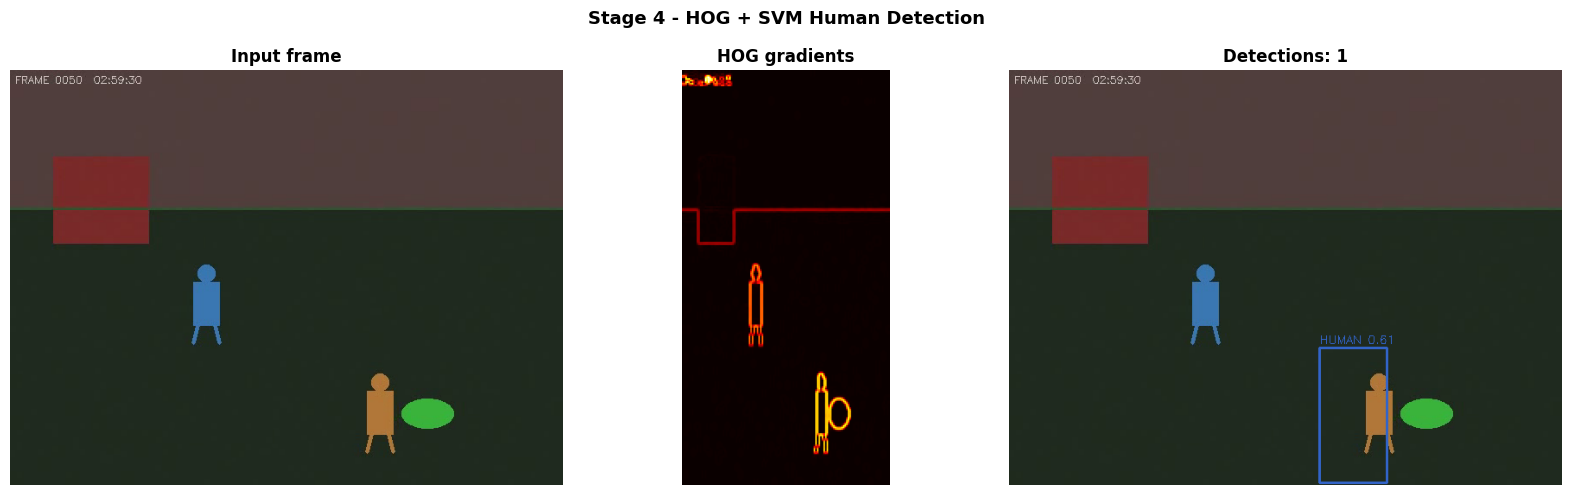

Human detector ready. Detections: 1


In [30]:
class HumanDetector:
    def __init__(self):
        self.hog = cv2.HOGDescriptor()
        self.hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())
        print('HOG+SVM loaded.')

    def detect(self, frame):
        boxes, weights = self.hog.detectMultiScale(
            frame,
            winStride=CONFIG['HOG_WIN_STRIDE'],
            padding=CONFIG['HOG_PADDING'],
            scale=CONFIG['HOG_SCALE']
        )
        if len(boxes) == 0:
            return [], []
        return self._nms(boxes, weights)

    def _nms(self, boxes, weights):
        boxes = np.array(boxes, dtype=np.float32)
        x1 = boxes[:, 0]; y1 = boxes[:, 1]
        x2 = boxes[:, 0] + boxes[:, 2]; y2 = boxes[:, 1] + boxes[:, 3]
        areas = (x2 - x1 + 1) * (y2 - y1 + 1)
        order = weights.flatten().argsort()[::-1]
        keep = []
        while order.size > 0:
            i = order[0]
            keep.append(i)
            xx1 = np.maximum(x1[i], x1[order[1:]])
            yy1 = np.maximum(y1[i], y1[order[1:]])
            xx2 = np.minimum(x2[i], x2[order[1:]])
            yy2 = np.minimum(y2[i], y2[order[1:]])
            w = np.maximum(0.0, xx2 - xx1 + 1)
            h = np.maximum(0.0, yy2 - yy1 + 1)
            iou = (w * h) / (areas[i] + areas[order[1:]] - (w * h))
            order = order[np.where(iou <= CONFIG['NMS_THRESHOLD'])[0] + 1]
        return [tuple(boxes[k].astype(int)) for k in keep], [weights.flatten()[k] for k in keep]

    def visualize_hog(self, frame):
        resized = cv2.resize(frame, (128, 256))
        gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
        sx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        sy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        mag = np.sqrt(sx**2 + sy**2)
        return (mag / mag.max() * 255).astype(np.uint8)

human_detector = HumanDetector()

# Ensure VIDEO_PATH points to a valid video source for demonstration
# The YouTube download failed in a previous cell, so use the generated test video
VIDEO_PATH = '/content/test_video.avi'

cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, 50)
ret, sample = cap.read()
cap.release()

if sample is not None:
    pp_data = preprocessor.process(sample)
    mag = human_detector.visualize_hog(pp_data['resized'])
    boxes, weights = human_detector.detect(pp_data['equalized'])
    vis = pp_data['resized'].copy()
    for (x, y, w, h), wt in zip(boxes, weights):
        cv2.rectangle(vis, (x, y), (x+w, y+h), (200, 100, 50), 2)
        cv2.putText(vis, 'HUMAN ' + str(round(wt, 2)), (x, y-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (200, 100, 50), 1)
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    axes[0].imshow(cv2.cvtColor(pp_data['resized'], cv2.COLOR_BGR2RGB))
    axes[0].set_title('Input frame', fontweight='bold')
    axes[1].imshow(mag, cmap='hot')
    axes[1].set_title('HOG gradients', fontweight='bold')
    axes[2].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    axes[2].set_title('Detections: ' + str(len(boxes)), fontweight='bold')
    for ax in axes: ax.axis('off')
    plt.suptitle('Stage 4 - HOG + SVM Human Detection', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print('Human detector ready. Detections: ' + str(len(boxes)))
elif not ret:
    print(f"Warning: Could not read frame from video at '{VIDEO_PATH}'. Skipping HOG detection demonstration.")
else:
    print(f"Warning: Sample frame is None from video at '{VIDEO_PATH}'. Skipping HOG detection demonstration.")

In [ ]:
class CentroidTracker:
    def __init__(self, max_disappeared=30):
        self.next_id = 0
        self.objects = {}
        self.disappeared = {}
        self.max_disappeared = max_disappeared

    def register(self, centroid):
        self.objects[self.next_id] = centroid
        self.disappeared[self.next_id] = 0
        self.next_id += 1

    def deregister(self, obj_id):
        del self.objects[obj_id]
        del self.disappeared[obj_id]

    def update(self, boxes):
        if len(boxes) == 0:
            for obj_id in list(self.disappeared.keys()):
                self.disappeared[obj_id] += 1
                if self.disappeared[obj_id] > self.max_disappeared:
                    self.deregister(obj_id)
            return self.objects
        input_centroids = np.array([(x + w//2, y + h//2) for (x, y, w, h) in boxes])
        if len(self.objects) == 0:
            for c in input_centroids:
                self.register(c)
        else:
            obj_ids = list(self.objects.keys())
            obj_centroids = list(self.objects.values())
            D = dist.cdist(np.array(obj_centroids), input_centroids)
            rows = D.min(axis=1).argsort()
            cols = D.argmin(axis=1)[rows]
            used_rows, used_cols = set(), set()
            for (r, c) in zip(rows, cols):
                if r in used_rows or c in used_cols: continue
                obj_id = obj_ids[r]
                self.objects[obj_id] = input_centroids[c]
                self.disappeared[obj_id] = 0
                used_rows.add(r); used_cols.add(c)
            for r in set(range(len(obj_centroids))) - used_rows:
                obj_id = obj_ids[r]
                self.disappeared[obj_id] += 1
                if self.disappeared[obj_id] > self.max_disappeared:
                    self.deregister(obj_id)
            for c in set(range(len(input_centroids))) - used_cols:
                self.register(input_centroids[c])
        return self.objects


class BehaviorClassifier:
    def __init__(self, history_len=30):
        self.history     = defaultdict(lambda: deque(maxlen=history_len))
        self.dwell_count = defaultdict(int)
        self.dwell_pos   = {}
        self.DWELL_RADIUS = 25

    def classify(self, obj_id, centroid, entity_type='human'):
        cx, cy = centroid
        self.history[obj_id].append((cx, cy))
        if len(self.history[obj_id]) < 2:
            return 'idle', 0.0
        prev  = self.history[obj_id][-2]
        speed = np.sqrt((cx - prev[0])**2 + (cy - prev[1])**2)
        if obj_id not in self.dwell_pos:
            self.dwell_pos[obj_id] = (cx, cy)
        else:
            dpx, dpy = self.dwell_pos[obj_id]
            if np.sqrt((cx-dpx)**2 + (cy-dpy)**2) < self.DWELL_RADIUS:
                self.dwell_count[obj_id] += 1
            else:
                self.dwell_count[obj_id] = 0
                self.dwell_pos[obj_id] = (cx, cy)
        dwell = self.dwell_count[obj_id]
        if entity_type == 'animal':
            if dwell > CONFIG['ANIMAL_STILL_FRAMES']: return 'stationary_alert', speed
            return ('grazing' if speed < CONFIG['IDLE_SPEED'] else 'moving'), speed
        if speed > CONFIG['WALKING_SPEED'] and dwell > CONFIG['LINGER_FRAMES'] // 3:
            return 'suspicious', speed
        elif speed > CONFIG['WALKING_SPEED']: return 'running', speed
        elif dwell > CONFIG['LINGER_FRAMES']:  return 'lingering', speed
        elif speed > CONFIG['IDLE_SPEED']:     return 'walking', speed
        else:                                  return 'idle', speed

print('CentroidTracker ready.')
print('BehaviorClassifier ready.')

In [ ]:
class AlertSystem:
    def __init__(self, log_path=None):
        self.log_path   = log_path or CONFIG['LOG_FILE']
        self.last_fired = {}
        self.alert_log  = []
        with open(self.log_path, 'w') as f:
            f.write('Surveillance Alert Log\n')
            f.write('Started: ' + str(datetime.datetime.now()) + '\n\n')

    def fire(self, key, message, level='HIGH', frame_num=0):
        now = time.time()
        if key in self.last_fired:
            if now - self.last_fired[key] < CONFIG['ALERT_COOLDOWN_S']:
                return False
        self.last_fired[key] = now
        ts    = datetime.datetime.now().strftime('%H:%M:%S')
        entry = {'ts': ts, 'frame': frame_num, 'level': level, 'key': key, 'message': message}
        self.alert_log.append(entry)
        log_line = '[' + ts + '] Frame ' + str(frame_num).zfill(4) + ' [' + level + '] ' + message
        print(log_line)
        with open(self.log_path, 'a') as f:
            f.write(log_line + '\n')
        return True

    def summary(self):
        print('\n=== Alert Summary ===')
        print('Total: ' + str(len(self.alert_log)))
        for lvl in ['HIGH', 'MEDIUM', 'LOW', 'INFO']:
            count = sum(1 for a in self.alert_log if a['level'] == lvl)
            print('  ' + lvl.ljust(8) + ': ' + str(count))

print('Alert system ready.')

In [ ]:
def draw_overlay(frame, frame_num, human_boxes, human_weights, animal_boxes, obj_behaviors, fps=20.0):
    vis  = frame.copy()
    H, W = vis.shape[:2]
    for i, ((x, y, w, h), wt) in enumerate(zip(human_boxes, human_weights)):
        behavior, _ = obj_behaviors.get('H' + str(i), ('walking', 0.0))
        color = BEHAVIOR_COLORS.get(behavior, (200, 200, 200))
        cv2.rectangle(vis, (x, y), (x+w, y+h), color, 2)
        cv2.putText(vis, 'HUMAN [' + behavior.upper() + '] ' + str(round(wt, 2)),
                    (x, y-6), cv2.FONT_HERSHEY_SIMPLEX, 0.42, color, 1, cv2.LINE_AA)
        cv2.circle(vis, (x + w//2, y + h//2), 3, color, -1)
    for j, (x, y, w, h) in enumerate(animal_boxes):
        behavior, _ = obj_behaviors.get('A' + str(j), ('idle', 0.0))
        color = (50, 170, 240) if 'alert' in behavior else (50, 200, 50)
        cv2.rectangle(vis, (x, y), (x+w, y+h), color, 2)
        cv2.putText(vis, 'ANIMAL [' + behavior.upper() + ']',
                    (x, y-6), cv2.FONT_HERSHEY_SIMPLEX, 0.42, color, 1, cv2.LINE_AA)
    cv2.rectangle(vis, (0, 0), (W, 28), (0, 0, 0), -1)
    cv2.putText(vis, 'CAM-01 | FRAME ' + str(frame_num).zfill(5) + ' | ' +
                datetime.datetime.now().strftime('%H:%M:%S') + ' | HOG+SVM + MOG2',
                (6, 18), cv2.FONT_HERSHEY_SIMPLEX, 0.42, (200, 200, 200), 1)
    if (frame_num // 15) % 2 == 0:
        cv2.circle(vis, (W-14, 14), 5, (50, 50, 220), -1)
        cv2.putText(vis, 'REC', (W-45, 19), cv2.FONT_HERSHEY_SIMPLEX, 0.38, (200, 200, 200), 1)
    cv2.rectangle(vis, (0, H-60), (220, H), (0, 0, 0), -1)
    cv2.putText(vis, 'Humans : ' + str(len(human_boxes)),  (6, H-44), cv2.FONT_HERSHEY_SIMPLEX, 0.42, (200, 200, 200), 1)
    cv2.putText(vis, 'Animals: ' + str(len(animal_boxes)), (6, H-28), cv2.FONT_HERSHEY_SIMPLEX, 0.42, (200, 200, 200), 1)
    cv2.putText(vis, 'FPS    : ' + str(round(fps, 1)),     (6, H-12), cv2.FONT_HERSHEY_SIMPLEX, 0.42, (200, 200, 200), 1)
    return vis


def run_pipeline(video_path, max_frames=None, display_every=15):
    pre       = Preprocessor()
    ani       = AnimalDetector()
    hum       = HumanDetector()
    h_tracker = CentroidTracker(max_disappeared=25)
    a_tracker = CentroidTracker(max_disappeared=40)
    beh       = BehaviorClassifier()
    alrt      = AlertSystem()
    cap       = cv2.VideoCapture(video_path)
    total     = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps       = cap.get(cv2.CAP_PROP_FPS) or 20.0
    writer    = cv2.VideoWriter(CONFIG['OUTPUT_VIDEO'], cv2.VideoWriter_fourcc(*'XVID'),
                                fps, (CONFIG['FRAME_WIDTH'], CONFIG['FRAME_HEIGHT']))
    stats, preview_frames, frame_idx, t0 = defaultdict(int), [], 0, time.time()
    print('Processing ' + str(total) + ' frames...')
    while True:
        ret, frame = cap.read()
        if not ret: break
        if max_frames and frame_idx >= max_frames: break
        pp         = pre.process(frame)
        _, ab, _   = ani.detect(pp['resized'])
        a_objects  = a_tracker.update(ab)
        hb, hw     = hum.detect(pp['equalized'])
        h_objects  = h_tracker.update(hb)
        obj_behaviors = {}
        h_keys = list(h_objects.keys())
        for obj_id, centroid in h_objects.items():
            behavior, speed = beh.classify(obj_id, centroid, 'human')
            obj_behaviors['H' + str(h_keys.index(obj_id))] = (behavior, speed)
            stats[behavior] += 1
            if behavior == 'suspicious':
                alrt.fire('sus_' + str(obj_id), 'Suspicious human ID ' + str(obj_id), 'HIGH', frame_idx)
            elif behavior == 'lingering':
                alrt.fire('lin_' + str(obj_id), 'Human lingering ID ' + str(obj_id), 'MEDIUM', frame_idx)
        a_keys = list(a_objects.keys())
        for obj_id, centroid in a_objects.items():
            behavior, speed = beh.classify(obj_id, centroid, 'animal')
            obj_behaviors['A' + str(a_keys.index(obj_id))] = (behavior, speed)
            if behavior == 'stationary_alert':
                alrt.fire('ani_' + str(obj_id), 'Animal stationary - welfare check ID ' + str(obj_id), 'MEDIUM', frame_idx)
        live_fps  = (frame_idx + 1) / max(time.time() - t0, 0.001)
        annotated = draw_overlay(pp['resized'], frame_idx, hb, hw, ab, obj_behaviors, live_fps)
        writer.write(annotated)
        if frame_idx % display_every == 0:
            preview_frames.append((frame_idx, annotated.copy()))
        frame_idx += 1
        if frame_idx % 50 == 0:
            print('  Frame ' + str(frame_idx) + '/' + str(total) +
                  '  FPS=' + str(round(live_fps, 1)) +
                  '  Humans=' + str(len(hb)) + '  Animals=' + str(len(ab)))
    cap.release()
    writer.release()
    alrt.summary()
    return stats, preview_frames, alrt.alert_log

stats, preview_frames, alert_log = run_pipeline(VIDEO_PATH)

In [ ]:
if preview_frames:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    for ax, (fi, frm) in zip(axes.flatten(), preview_frames[:6]):
        ax.imshow(cv2.cvtColor(frm, cv2.COLOR_BGR2RGB))
        ax.set_title('Frame ' + str(fi))
        ax.axis('off')
    plt.suptitle('Annotated Output Frames', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

behavior_keys = ['idle', 'walking', 'lingering', 'suspicious', 'running']
behavior_vals = [stats.get(k, 0) for k in behavior_keys]
colors_mpl    = ['#639922', '#378ADD', '#EF9F27', '#E24B4A', '#FF6B00']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bars = axes[0].bar(behavior_keys, behavior_vals, color=colors_mpl, edgecolor='white')
axes[0].set_title('Behavior Distribution', fontweight='bold')
axes[0].set_xlabel('Behavior')
axes[0].set_ylabel('Frame count')
axes[0].spines[['top', 'right']].set_visible(False)
for bar, val in zip(bars, behavior_vals):
    if val > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     str(val), ha='center', fontsize=10)
alert_levels = {}
for a in alert_log:
    alert_levels[a['level']] = alert_levels.get(a['level'], 0) + 1
if alert_levels:
    pie_colors = {'HIGH':'#E24B4A','MEDIUM':'#EF9F27','LOW':'#639922','INFO':'#378ADD'}
    axes[1].pie(list(alert_levels.values()), labels=list(alert_levels.keys()),
                colors=[pie_colors.get(l,'#888') for l in alert_levels],
                autopct='%1.0f%%', startangle=140,
                wedgeprops={'edgecolor':'white','linewidth':1})
    axes[1].set_title('Alert Breakdown', fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'No alerts fired', ha='center', va='center',
                 transform=axes[1].transAxes, fontsize=12, color='gray')
    axes[1].set_title('Alert Breakdown', fontweight='bold')
plt.tight_layout()
plt.show()
if alert_log:
    print('\n=== Alert Log ===')
    for a in alert_log:
        print(str(a['ts']).ljust(12) + str(a['frame']).ljust(8) + str(a['level']).ljust(10) + str(a['message']))

In [ ]:
cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, 80)
ret, test_frame = cap.read()
cap.release()
pp_test = preprocessor.process(test_frame)

t0 = time.time()
for _ in range(10): hboxes, hwts = human_detector.detect(pp_test['equalized'])
hog_time = (time.time() - t0) / 10 * 1000

ani2 = AnimalDetector()
t0 = time.time()
for _ in range(10): _, aboxes, _ = ani2.detect(pp_test['resized'])
mog_time = (time.time() - t0) / 10 * 1000

vis_hog = pp_test['resized'].copy()
for (x, y, w, h), wt in zip(hboxes, hwts):
    cv2.rectangle(vis_hog, (x, y), (x+w, y+h), (200, 100, 50), 2)
    cv2.putText(vis_hog, 'HOG ' + str(round(wt, 2)), (x, y-5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.42, (200, 100, 50), 1)

vis_mog = pp_test['resized'].copy()
_, aboxes2, _ = ani2.detect(pp_test['resized'])
for (x, y, w, h) in aboxes2:
    cv2.rectangle(vis_mog, (x, y), (x+w, y+h), (50, 200, 50), 2)
    cv2.putText(vis_mog, 'MOG2', (x, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.42, (50, 200, 50), 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(vis_hog, cv2.COLOR_BGR2RGB))
axes[0].set_title('HOG+SVM | ' + str(round(hog_time,1)) + 'ms | ' + str(len(hboxes)) + ' detections', fontweight='bold')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(vis_mog, cv2.COLOR_BGR2RGB))
axes[1].set_title('MOG2 | ' + str(round(mog_time,1)) + 'ms | ' + str(len(aboxes2)) + ' detections', fontweight='bold')
axes[1].axis('off')
plt.suptitle('Algorithm Comparison - Same Frame', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('='*60)
rows = [
    ('Task',                    'Human detection',      'Motion/animal'),
    ('Latency (ms)',             str(round(hog_time,1)), str(round(mog_time,1))),
    ('Needs training data',     'Pre-trained (INRIA)',  'No (unsupervised)'),
    ('Works with static cam',   'Yes',                  'Yes'),
    ('Handles lighting change', 'Moderate',             'Good (adaptive)'),
    ('False positives',         'Low (SVM)',            'Medium (noise)'),
    ('Best for',                'Person detection',     'Any moving object'),
]
for r in rows:
    print(r[0].ljust(28) + r[1].ljust(22) + r[2])
print('='*60)

In [31]:
for path, desc in [(CONFIG['OUTPUT_VIDEO'], 'Annotated video'), (CONFIG['LOG_FILE'], 'Alert log')]:
    if os.path.exists(path):
        print('Downloading: ' + desc + ' (' + str(round(os.path.getsize(path)/1024, 1)) + ' KB)')
        files.download(path)
    else:
        print('Not found: ' + path)

print('\nAll done!')

Downloading: Annotated video (1624.1 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: Alert log (0.1 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All done!


In [39]:
# Download files
for path, desc in [(CONFIG['OUTPUT_VIDEO'], 'Annotated video'), (CONFIG['LOG_FILE'], 'Alert log')]:
    if os.path.exists(path):
        print('Downloading: ' + desc + ' (' + str(round(os.path.getsize(path)/1024, 1)) + ' KB)')
        files.download(path)
    else:
        print('Not found: ' + path)

print('All done!')

# ── Convert AVI to MP4 and play in notebook ──────────────────────────────────
import subprocess
from IPython.display import HTML
from base64 import b64encode

subprocess.run([
    'ffmpeg', '-i', '/content/surveillance_output.avi',
    '-vcodec', 'libx264', '-crf', '23', '-preset', 'fast',
    '-pix_fmt', 'yuv420p',
    '/content/surveillance_output.mp4', '-y'
], capture_output=True)

mp4 = open('/content/surveillance_output.mp4', 'rb').read()
data_url = 'data:video/mp4;base64,' + b64encode(mp4).decode()
HTML('''
<video width="640" height="480" controls autoplay>
    <source src="''' + data_url + '''" type="video/mp4">
</video>
''')

Downloading: Annotated video (1624.1 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: Alert log (0.1 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All done!
